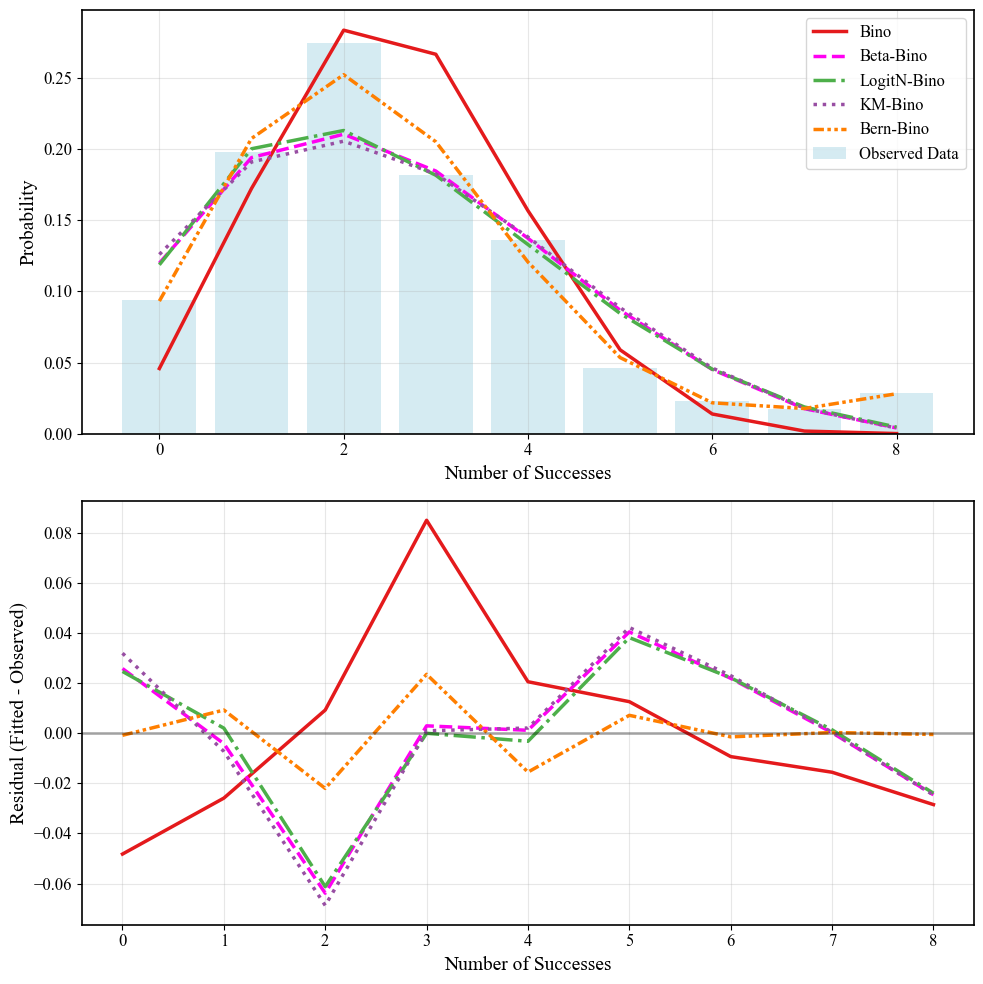

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from matplotlib import rcParams
import seaborn as sns
from scipy.stats import binom, beta, norm
from scipy.special import expit, logit
import matplotlib.gridspec as gridspec

# 设置学术论文风格
def set_academic_style():
    """设置学术论文风格的绘图参数"""
    plt.style.use('default')
    rcParams['font.family'] = 'serif'
    rcParams['font.serif'] = ['Times New Roman']
    rcParams['mathtext.fontset'] = 'stix'
    rcParams['font.size'] = 12
    rcParams['axes.labelsize'] = 14
    rcParams['axes.titlesize'] = 16
    rcParams['xtick.labelsize'] = 12
    rcParams['ytick.labelsize'] = 12
    rcParams['legend.fontsize'] = 12
    rcParams['figure.figsize'] = (10, 6)
    rcParams['figure.dpi'] = 100
    rcParams['savefig.dpi'] = 300
    rcParams['axes.linewidth'] = 1.2
    rcParams['lines.linewidth'] = 2
    rcParams['grid.linewidth'] = 0.8
    rcParams['grid.alpha'] = 0.25

# 设置样式
set_academic_style()

# 读取数据
sample_data = pd.read_csv(r'E:\Thesis\BSB\Real Data Analysis\Mobility数据\results\scores_train.csv')
x = sample_data['score'].values
n_trials = 8  # 二项分布试验次数
sample_size = 5912

# 2. 模型拟合结果
models = ['Bino', 'Beta-Bino', 'LogitN-Bino', 'KM-Bino', 'Bern-Bino']
# 模型参数 (这里只是示例，请替换为您的实际参数)
model_params = {
    'Bino': (0.3198),
    'Beta-Bino': (2.4661, 5.1846),
    'LogitN-Bino': (-0.8580, 0.8233),
    'KM-Bino': (1.8854, 5.9790),
    'Bern-Bino': np.array([0.00880, 0.00000, 0.00000, 0.00000, 0.00000, 0.00000, 
                           0.16010, 0.77965, 0.00000, 0.00000, 0.00000, 0.00000, 0.00000, 
                           0.00000, 0.00000, 0.00000, 0.00000, 0.00000, 0.00000, 0.00000, 
                           0.00000, 0.00000, 0.00006, 0.03353, 0.00005, 0.01781])
}

# 定义各种先验分布的概率密度函数
def beta_prior(p, a, b):
    return beta.pdf(p, a, b)

def logit_normal_prior(p, mu, sigma):
    with np.errstate(divide='ignore', invalid='ignore'):
        mask = (p > 0) & (p < 1)
        result = np.zeros_like(p)
        result[mask] = norm.pdf(logit(p[mask]), mu, sigma) / (p[mask] * (1 - p[mask]))
        return result

def kumaraswamy_prior(p, a, b):
    return a * b * (p ** (a - 1)) * ((1 - p ** a) ** (b - 1))

def bernstein_prior(p, weights):
    K = len(weights) - 1
    result = np.zeros_like(p)
    for k in range(K + 1):
        result += weights[k] * beta.pdf(p, k + 1, K - k + 1)
    return result

# 计算二项分布的概率质量函数（考虑先验）
def binomial(k, n, p):
    """计算二项分布的概率质量函数"""
    return binom.pmf(k, n, p)

def binomial_with_prior_pmf(k, n, prior_func, prior_params):
    """计算考虑先验的二项分布概率质量函数"""
    # 数值积分计算边缘分布
    p_values = np.linspace(0.001, 0.999, 1000)
    prior_probs = prior_func(p_values, *prior_params)
    
    # 归一化先验概率
    prior_probs /= np.trapezoid(prior_probs, p_values)
    
    # 计算每个k值的概率
    pmf = np.zeros_like(k, dtype=float)
    for i, k_val in enumerate(k):
        # 二项分布概率
        binom_probs = binom.pmf(k_val, n, p_values)
        # 边缘概率
        pmf[i] = np.trapezoid(binom_probs * prior_probs, p_values)
    
    return pmf

# 1. 拟合优度对比图
def plot_fit_comparison():
    """绘制拟合优度对比图"""
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 10))
    
    # 计算观测数据的直方图
    k_values = np.arange(0, n_trials + 1)
    observed_freq, _ = np.histogram(sample_data, bins=np.arange(-0.5, n_trials + 1.5))
    observed_prob = observed_freq / sample_size
    
    # 绘制观测数据
    ax1.bar(k_values, observed_prob, alpha=0.5, color="lightblue", label='Observed Data')
    
    # 定义颜色和线型
    colors = ['#E41A1C', "#FF00F2", '#4DAF4A', '#984EA3', '#FF7F00']
    linestyles = ['-', '--', '-.', ':', (0, (3, 1, 1, 1, 1, 1))]
    
    # 绘制各模型的拟合曲线
    for i, model in enumerate(models):
        # 计算模型预测的概率
        if model == 'Bern-Bino':
            model_pmf = binomial_with_prior_pmf(k_values, n_trials, bernstein_prior, [model_params[model]])
        elif model == 'Beta-Bino':
            model_pmf = binomial_with_prior_pmf(k_values, n_trials, beta_prior, model_params[model])
        elif model == 'LogitN-Bino':
            model_pmf = binomial_with_prior_pmf(k_values, n_trials, logit_normal_prior, model_params[model])
        elif model == 'KM-Bino':
            model_pmf = binomial_with_prior_pmf(k_values, n_trials, kumaraswamy_prior, model_params[model])
        elif model == 'Bino':
            model_pmf = binomial(k_values, n_trials, model_params[model])
        
        # 绘制模型拟合曲线
        ax1.plot(k_values, model_pmf, color=colors[i], linestyle=linestyles[i], 
                linewidth=2.5, label=model)
        
        # 计算残差
        residuals = model_pmf - observed_prob
        ax2.plot(k_values, residuals, color=colors[i], linestyle=linestyles[i],
                linewidth=2.5, label=model)
    
    # 设置第一个子图
    ax1.set_xlabel('Number of Successes')
    ax1.set_ylabel('Probability')
    # ax1.set_title('Goodness-of-Fit Comparison for Binomial Distribution')
    ax1.legend(loc='upper right')
    ax1.grid(True, alpha=0.3)
    
    # 设置第二个子图（残差图）
    ax2.axhline(y=0, color='black', linestyle='-', alpha=0.3)
    ax2.set_xlabel('Number of Successes')
    ax2.set_ylabel('Residual (Fitted - Observed)')
    # ax2.set_title('Residual Plot')
    ax2.grid(True, alpha=0.3)
    
    plt.tight_layout()
    return fig

# 生成所有图形
fig1 = plot_fit_comparison()

# 显示图形
plt.savefig('plot_train', dpi=800, bbox_inches='tight', pad_inches=0.1)
plt.show()
